## Predicting High Value Customers

### Step 1: Load and Explore Customer Data

In [1]:
import pandas as pd

# Load data
df = pd.read_csv('synthetic_retail_customers.csv')

# Display basic info
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

# Summary statistics to understand spending and frequency patterns
print("\nSummary Statistics:")
print(df.describe())

Dataset Shape: (1000, 7)

First 5 rows:
   customer_id  avg_spend_per_visit  visit_frequency_per_month  \
0         1001            43.708611                          5   
1         1002            95.564288                          4   
2         1003            75.879455                          2   
3         1004            63.879264                          5   
4         1005            24.041678                          8   

   menu_engagement_score  online_order_ratio  loyalty_years  is_high_value  
0               1.353385            0.433442              5              0  
1               9.795554            0.294992              5              1  
2               3.181183            0.016162              3              0  
3               6.969796            0.140819              3              1  
4               8.551897            0.438305              1              0  

Summary Statistics:
       customer_id  avg_spend_per_visit  visit_frequency_per_month  \
count  100

### Step 2: Visualize Key Features

/var/folders/k5/rnrtn2ld6fsg4r3135y8rph40000gn/T/ipykernel_32495/3967638440.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


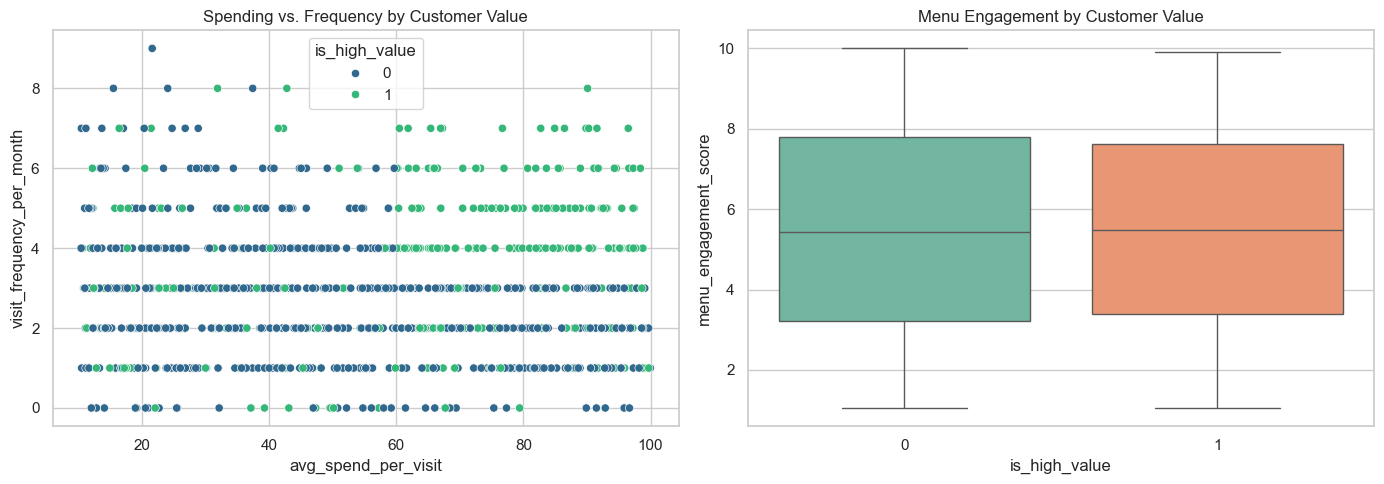

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Create a figure with three plots to be extra thorough
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# 1. Correlation Heatmap (Great for spotting patterns early)
corr = df.drop(columns=["customer_id"]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=ax[0])
ax[0].set_title("Feature Correlation Matrix")

# 2. Spending vs Visit Frequency (The core "Value" drivers)
sns.scatterplot(
    data=df,
    x="avg_spend_per_visit",
    y="visit_frequency_per_month",
    hue="is_high_value",
    palette="viridis",
    ax=ax[1],
)
ax[1].set_title("Spending vs. Frequency")

# 3. Menu Engagement (Fixed the Deprecation Warning)
sns.boxplot(
    data=df,
    x="is_high_value",
    y="menu_engagement_score",
    hue="is_high_value",
    palette="Set2",
    legend=False,
    ax=ax[2],
)
ax[2].set_title("Menu Engagement by Category")

plt.tight_layout()
plt.show()